In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

# Core enrollment features (behavioral baseline)
core_enrol_df = pd.read_csv(
    "../Data/Feature_Data/feature_enrolment.csv",
    parse_dates=["date"]
)

# Advanced enrollment features (instability & stress signals)
adv_enrol_df = pd.read_csv(
    "../Data/Advanced_Feature_Data/advanced_feature_enrolment.csv",
    parse_dates=["date"]
)

# Structural sanity check (no validation)
core_enrol_df.head()


,date,state_clean,district_clean,pincode,age_0_5,age_5_17,age_18_greater,year,month,quarter,week_of_year,day_of_week,is_weekend,total_enrolments,child_enrolments,adult_ratio,child_share
0,2025-03-02,Meghalaya,east khasi hills,793121,11,61,37,2025,3,1,9,6,1,109,72,0.339450,0.660550
1,2025-03-09,Karnataka,bengaluru urban,560043,14,33,39,2025,3,1,10,6,1,86,47,0.453488,0.546512
2,2025-03-09,Uttar Pradesh,kanpur nagar,208001,29,82,12,2025,3,1,10,6,1,123,111,0.097561,0.902439
3,2025-03-09,Uttar Pradesh,aligarh,202133,62,29,15,2025,3,1,10,6,1,106,91,0.141509,0.858491
4,2025-03-09,Karnataka,bengaluru urban,560016,14,16,21,2025,3,1,10,6,1,51,30,0.411765,0.588235


In [8]:
# Shape and column overview
print("Core Enrollment Features Shape:", core_enrol_df.shape)
print("Advanced Enrollment Features Shape:", adv_enrol_df.shape)

print("\nCore Enrollment Columns:")
display(pd.DataFrame({
    "column": core_enrol_df.columns,
    "dtype": core_enrol_df.dtypes.astype(str)
}))

print("\nAdvanced Enrollment Columns:")
display(pd.DataFrame({
    "column": adv_enrol_df.columns,
    "dtype": adv_enrol_df.dtypes.astype(str)
}))


Core Enrollment Features Shape: (994925, 17)
Advanced Enrollment Features Shape: (994925, 24)

Core Enrollment Columns:


,column,dtype
date,date,datetime64[ns]
state_clean,state_clean,object
district_clean,district_clean,object
pincode,pincode,int64
age_0_5,age_0_5,int64
age_5_17,age_5_17,int64
age_18_greater,age_18_greater,int64
year,year,int64
month,month,int64
quarter,quarter,int64



Advanced Enrollment Columns:


,column,dtype
date,date,datetime64[ns]
state_clean,state_clean,object
district_clean,district_clean,object
pincode,pincode,int64
age_0_5,age_0_5,int64
age_5_17,age_5_17,int64
age_18_greater,age_18_greater,int64
year,year,int64
month,month,int64
quarter,quarter,int64


In [7]:
feature_groups = {
    "Temporal": ["date", "year", "month", "quarter", "week_of_year", "day_of_week", "is_weekend"],
    "Geographic": ["state_clean", "district_clean", "pincode"],
    "Volume": ["age_0_5", "age_5_17", "age_18_greater", "total_enrolments", "child_enrolments"],
    "Composition": ["adult_ratio", "child_share"]
}

for group, cols in feature_groups.items():
    print(f"\n{group} Features")
    display(core_enrol_df[cols].dtypes)



Temporal Features


date            datetime64[ns]
year                     int64
month                    int64
quarter                  int64
week_of_year             int64
day_of_week              int64
is_weekend               int64
dtype: object


Geographic Features


state_clean       object
district_clean    object
pincode            int64
dtype: object


Volume Features


age_0_5             int64
age_5_17            int64
age_18_greater      int64
total_enrolments    int64
child_enrolments    int64
dtype: object


Composition Features


adult_ratio    float64
child_share    float64
dtype: object

In [9]:
def date_diagnostics(df, name):
    print(f"\n📊 {name}")
    print("Date range:", df["date"].min(), "→", df["date"].max())
    print("Total days:", df["date"].nunique())
    print("Duplicate dates:", df["date"].duplicated().sum())

date_diagnostics(core_enrol_df, "Core Enrollment Features")
date_diagnostics(adv_enrol_df, "Advanced Enrollment Features")



📊 Core Enrollment Features
Date range: 2025-03-02 00:00:00 → 2025-12-31 00:00:00
Total days: 92
Duplicate dates: 994833

📊 Advanced Enrollment Features
Date range: 2025-03-02 00:00:00 → 2025-12-31 00:00:00
Total days: 92
Duplicate dates: 994833


In [11]:
# Cell 2B-2: Validate grain consistency (date × state × district × pincode)

grain_cols = ["date", "state_clean", "district_clean", "pincode"]

core_grain_check = core_enrol_df.duplicated(subset=grain_cols).sum()
adv_grain_check = adv_enrol_df.duplicated(subset=grain_cols).sum()

print("Core duplicate grain rows:", core_grain_check)
print("Advanced duplicate grain rows:", adv_grain_check)


Core duplicate grain rows: 25783
Advanced duplicate grain rows: 25783


In [13]:
# Cell 2B-3: Confirm row-level alignment between core and advanced datasets

core_keys = core_enrol_df[["date", "state_clean", "district_clean", "pincode"]]
adv_keys = adv_enrol_df[["date", "state_clean", "district_clean", "pincode"]]

print("Core rows:", len(core_keys))
print("Advanced rows:", len(adv_keys))
print("Key mismatch count:",
      len(core_keys.merge(adv_keys, how="outer", indicator=True)
          .query("_merge != 'both'")))


Core rows: 994925
Advanced rows: 994925
Key mismatch count: 0


In [14]:
# Cell 2B-4: System-level daily aggregation (analysis-only, no data mutation)

daily_core = (
    core_enrol_df
    .groupby("date", as_index=False)["total_enrolments"]
    .sum()
    .sort_values("date")
)

daily_core.head(), daily_core.tail()


(        date  total_enrolments
 0 2025-03-02               109
 1 2025-03-09              3404
 2 2025-03-15              3102
 3 2025-03-20              6218
 4 2025-03-23               576,
          date  total_enrolments
 87 2025-12-26             51643
 88 2025-12-27             52472
 89 2025-12-28             45124
 90 2025-12-29             58587
 91 2025-12-31            124058)

In [15]:
# Cell 2B-5: Day-over-day change and percent change (system behavior)

daily_core["day_change"] = daily_core["total_enrolments"].diff()
daily_core["pct_change"] = daily_core["total_enrolments"].pct_change() * 100

daily_core.head()


,date,total_enrolments,day_change,pct_change
0,2025-03-02,109,NaN,NaN
1,2025-03-09,3404,3295.0,3022.935780
2,2025-03-15,3102,-302.0,-8.871915
3,2025-03-20,6218,3116.0,100.451322
4,2025-03-23,576,-5642.0,-90.736571


In [16]:
# Cell 2B-6: Rolling volatility and stability signals (7-day window)

daily_core["rolling_mean_7d"] = (
    daily_core["total_enrolments"]
    .rolling(window=7, min_periods=3)
    .mean()
)

daily_core["rolling_std_7d"] = (
    daily_core["total_enrolments"]
    .rolling(window=7, min_periods=3)
    .std()
)

daily_core[["date", "total_enrolments", "rolling_mean_7d", "rolling_std_7d"]].head(10)


,date,total_enrolments,rolling_mean_7d,rolling_std_7d
0,2025-03-02,109,NaN,NaN
1,2025-03-09,3404,NaN,NaN
2,2025-03-15,3102,2205.000000,1821.459031
3,2025-03-20,6218,3208.250000,2497.569001
4,2025-03-23,576,2681.800000,2462.546690
5,2025-03-26,211,2270.000000,2422.557409
6,2025-03-27,2704,2332.000000,2217.557590
7,2025-03-28,191,2343.714286,2204.032722
8,2025-03-29,67,1867.000000,2295.466111
9,2025-04-01,257206,38167.571429,96612.606391


In [17]:
# Cell 2B-7: Volatility normalization (coefficient of variation)

daily_core["volatility_index"] = (
    daily_core["rolling_std_7d"] / daily_core["rolling_mean_7d"]
)

daily_core[["date", "volatility_index"]].dropna().head(10)


,date,volatility_index
2,2025-03-15,0.826059
3,2025-03-20,0.778483
4,2025-03-23,0.918244
5,2025-03-26,1.067206
6,2025-03-27,0.950925
7,2025-03-28,0.940402
8,2025-03-29,1.229494
9,2025-04-01,2.531275
10,2025-05-01,1.721271
11,2025-06-01,1.257759


In [18]:
# Cell 2B-8: Flag high-instability days (relative stress proxy)

vol_threshold = daily_core["volatility_index"].quantile(0.90)

daily_core["stress_flag"] = daily_core["volatility_index"] > vol_threshold

daily_core[["date", "volatility_index", "stress_flag"]].tail(10)


,date,volatility_index,stress_flag
82,2025-12-21,0.583186,False
83,2025-12-22,0.543338,False
84,2025-12-23,0.493199,False
85,2025-12-24,0.535525,False
86,2025-12-25,0.575508,False
87,2025-12-26,0.587875,False
88,2025-12-27,0.448970,False
89,2025-12-28,0.394671,False
90,2025-12-29,0.089997,False
91,2025-12-31,0.458917,False


In [52]:
pip install plotly


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 12.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.6/9.9 MB 6.5 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 5.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 6.0 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.9 MB 5.6 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 5.4 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 4.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.5 MB/s eta 0:00:00

   ------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
pip install --upgrade nbformat ipython jupyterlab


Defaulting to user installation because normal site-packages is not writeable
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached async_lru-2.0.5-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.met


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
pip install mplcursors


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


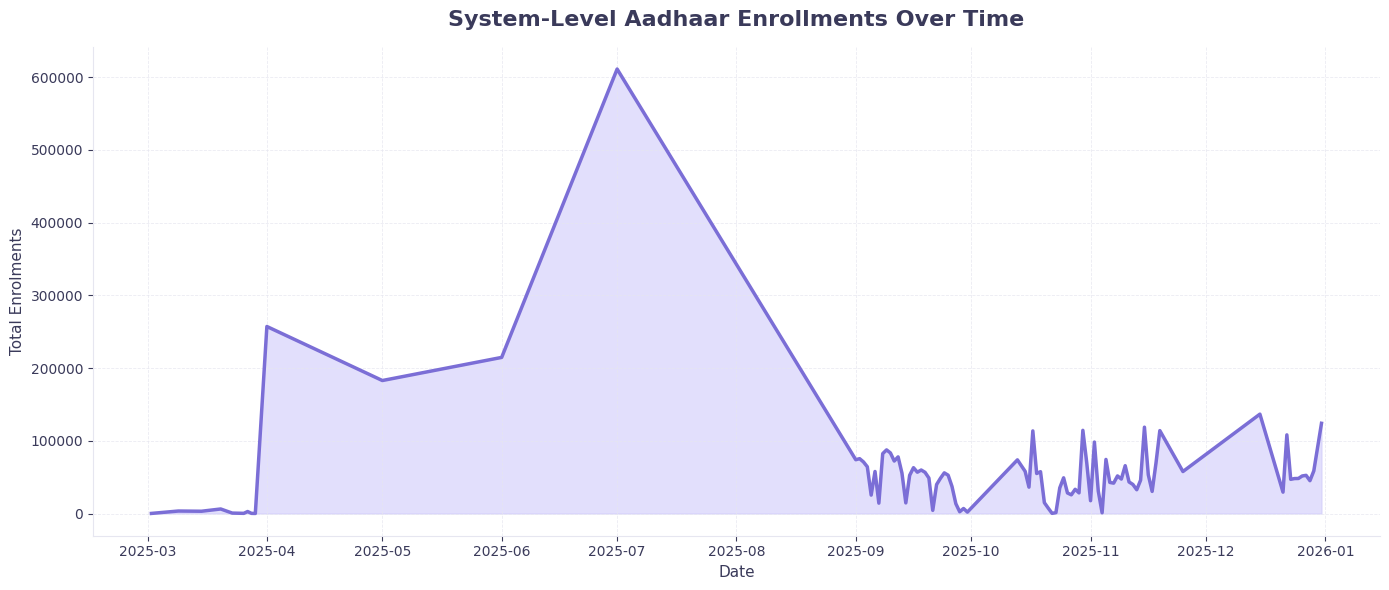

In [58]:
import matplotlib.pyplot as plt
import mplcursors

# Dashboard color palette
PRIMARY_PURPLE = "#7B6ED6"
FILL_PURPLE = "#CFCBFA"
GRID_COLOR = "#E6E6F0"
TEXT_COLOR = "#3A3A5A"

fig, ax = plt.subplots(figsize=(14, 6))

# Line plot
line, = ax.plot(
    daily_core["date"],
    daily_core["total_enrolments"],
    color=PRIMARY_PURPLE,
    linewidth=2.5
)

# Area fill
ax.fill_between(
    daily_core["date"],
    daily_core["total_enrolments"],
    color=FILL_PURPLE,
    alpha=0.6
)

# Titles & labels
ax.set_title(
    "System-Level Aadhaar Enrollments Over Time",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel("Date", fontsize=11, color=TEXT_COLOR)
ax.set_ylabel("Total Enrolments", fontsize=11, color=TEXT_COLOR)

# Grid styling
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    color=GRID_COLOR,
    alpha=0.8
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)

ax.tick_params(colors=TEXT_COLOR)

# 🔥 Hover interaction
cursor = mplcursors.cursor(line, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    sel.annotation.set_text(
        f"Date: {x}\nEnrolments: {int(y):,}"
    )
    sel.annotation.get_bbox_patch().set(fc="white", alpha=0.9)

plt.tight_layout()
plt.show()


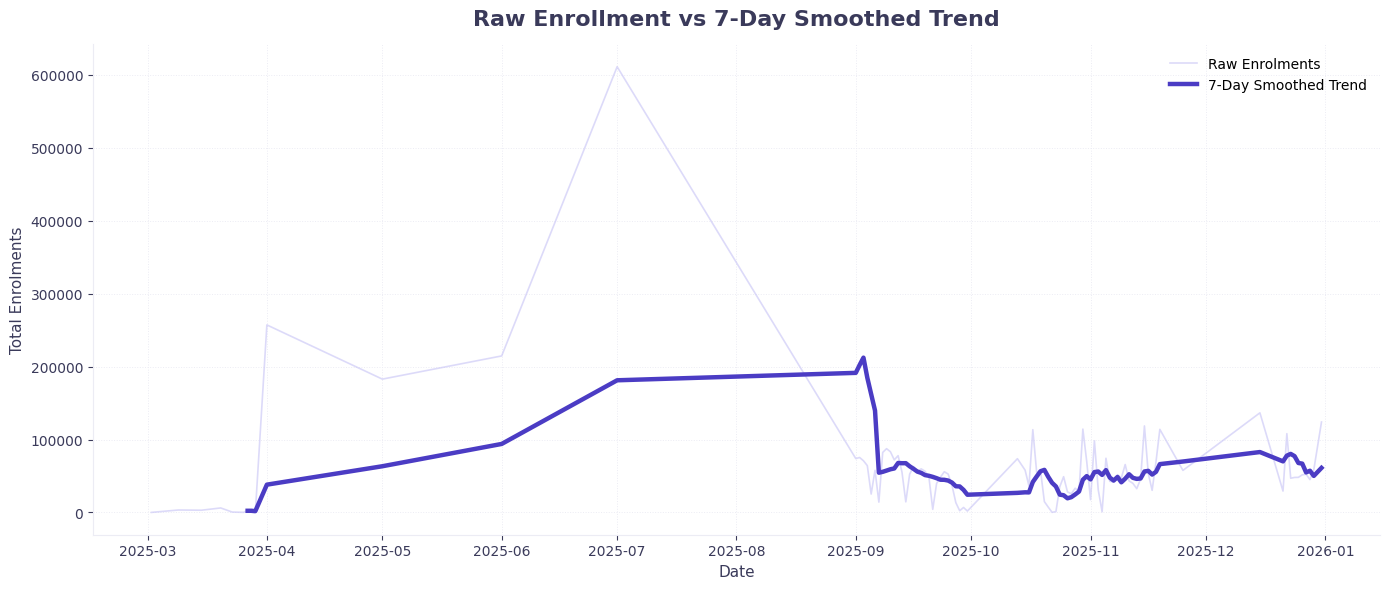

In [62]:
import matplotlib.pyplot as plt
import mplcursors

# Aadhaar-style calm palette
RAW_COLOR = "#C6C2F5"      # very soft lavender
SMOOTH_COLOR = "#4B3CC4"   # deep official purple
GRID_COLOR = "#ECECF4"
TEXT_COLOR = "#3A3A5A"

fig, ax = plt.subplots(figsize=(14, 6))

# Raw enrolments (background context only)
raw_line, = ax.plot(
    daily_core["date"],
    daily_core["total_enrolments"],
    color=RAW_COLOR,
    linewidth=1.2,
    alpha=0.6,
    label="Raw Enrolments"
)

# 7-day smoothed trend (main signal)
smooth_line, = ax.plot(
    daily_core["date"],
    daily_core["rolling_7d"],
    color=SMOOTH_COLOR,
    linewidth=3.2,
    label="7-Day Smoothed Trend"
)

# Title & labels (quiet, not shouting)
ax.set_title(
    "Raw Enrollment vs 7-Day Smoothed Trend",
    fontsize=16,
    fontweight="semibold",
    color=TEXT_COLOR,
    pad=14
)

ax.set_xlabel("Date", fontsize=11, color=TEXT_COLOR)
ax.set_ylabel("Total Enrolments", fontsize=11, color=TEXT_COLOR)

# Subtle grid
ax.grid(
    True,
    linestyle=":",
    linewidth=0.7,
    color=GRID_COLOR
)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)

ax.tick_params(colors=TEXT_COLOR)

ax.legend(frameon=False)

# Hover (only values, nothing flashy)
cursor = mplcursors.cursor([raw_line, smooth_line], hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    sel.annotation.set_text(f"{int(y):,}")
    sel.annotation.get_bbox_patch().set(
        fc="white",
        alpha=0.9
    )

plt.tight_layout()
plt.show()


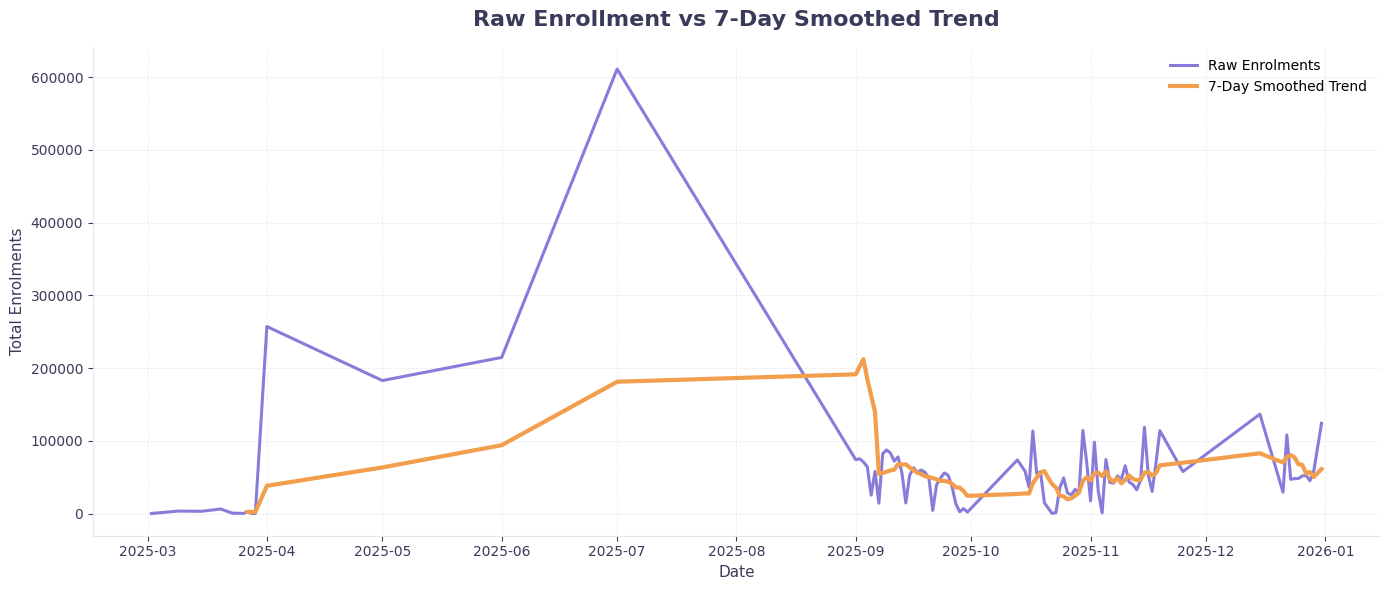

In [59]:
import matplotlib.pyplot as plt
import mplcursors

# Color palette (dashboard style)
RAW_COLOR = "#7B6ED6"        # purple (raw)
SMOOTH_COLOR = "#F29E4C"     # soft orange (smoothed)
GRID_COLOR = "#E6E6F0"
TEXT_COLOR = "#3A3A5A"

fig, ax = plt.subplots(figsize=(14, 6))

# Raw enrollment line
raw_line, = ax.plot(
    daily_core["date"],
    daily_core["total_enrolments"],
    color=RAW_COLOR,
    linewidth=2.2,
    label="Raw Enrolments",
    alpha=0.9
)

# 7-day smoothed line
smooth_line, = ax.plot(
    daily_core["date"],
    daily_core["rolling_7d"],
    color=SMOOTH_COLOR,
    linewidth=3,
    label="7-Day Smoothed Trend"
)

# Title & labels
ax.set_title(
    "Raw Enrollment vs 7-Day Smoothed Trend",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel("Date", fontsize=11, color=TEXT_COLOR)
ax.set_ylabel("Total Enrolments", fontsize=11, color=TEXT_COLOR)

# Grid
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    color=GRID_COLOR,
    alpha=0.8
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)

ax.tick_params(colors=TEXT_COLOR)

# Legend
ax.legend(frameon=False)

# 🔥 Hover interaction for BOTH lines
cursor = mplcursors.cursor([raw_line, smooth_line], hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    label = sel.artist.get_label()

    sel.annotation.set_text(
        f"{label}\nDate: {x}\nValue: {int(y):,}"
    )
    sel.annotation.get_bbox_patch().set(fc="white", alpha=0.95)

plt.tight_layout()
plt.show()


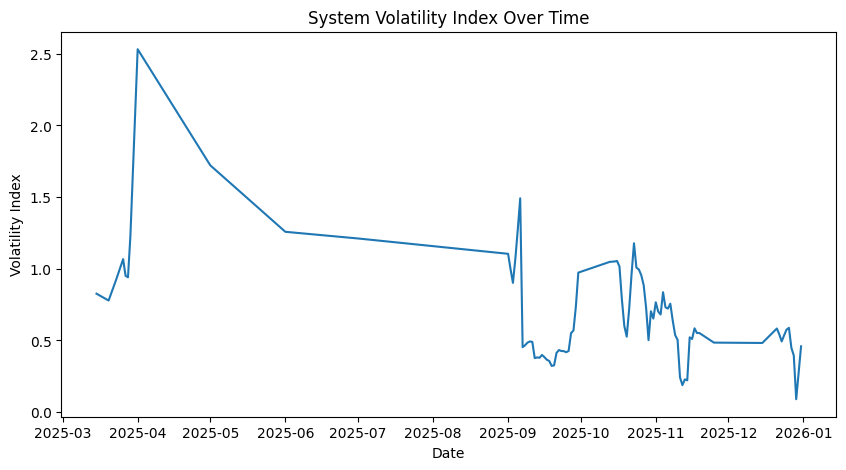

In [21]:
# Cell 3-3: Volatility vs level — detect friction vs saturation

plt.figure()
plt.plot(daily_core["date"], daily_core["volatility_index"])
plt.title("System Volatility Index Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility Index")
plt.show()


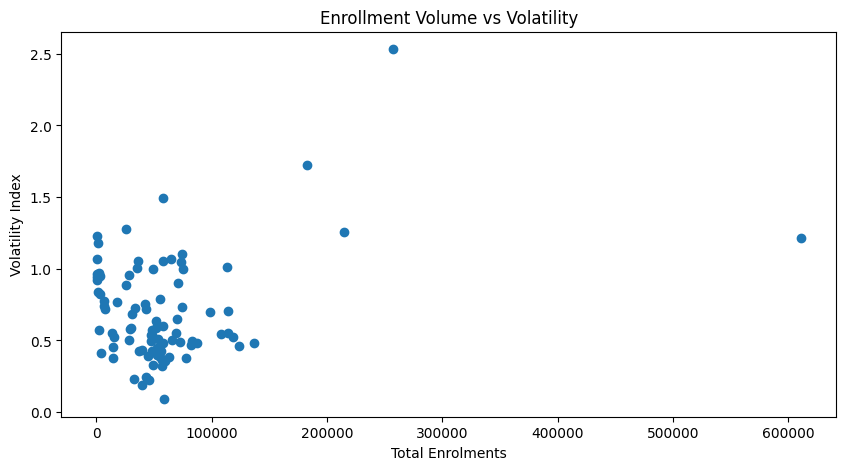

In [22]:
# Cell 3-4: Stability regimes — enrollment level vs volatility

plt.figure()
plt.scatter(
    daily_core["total_enrolments"],
    daily_core["volatility_index"]
)
plt.title("Enrollment Volume vs Volatility")
plt.xlabel("Total Enrolments")
plt.ylabel("Volatility Index")
plt.show()


In [23]:
# Cell 3-5: Identify potential saturation or friction periods

high_vol_low_growth = daily_core[
    (daily_core["volatility_index"] > daily_core["volatility_index"].median()) &
    (daily_core["day_change"].abs() < daily_core["day_change"].median())
]

high_vol_low_growth[["date", "total_enrolments", "volatility_index"]].head(10)


,date,total_enrolments,volatility_index


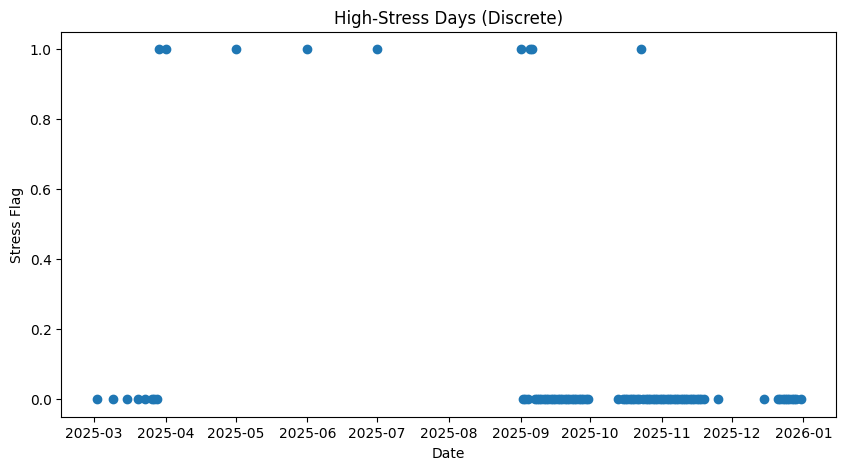

In [25]:
plt.figure()
plt.scatter(
    daily_core["date"],
    daily_core["stress_flag"].astype(int)
)
plt.title("High-Stress Days (Discrete)")
plt.xlabel("Date")
plt.ylabel("Stress Flag")
plt.show()


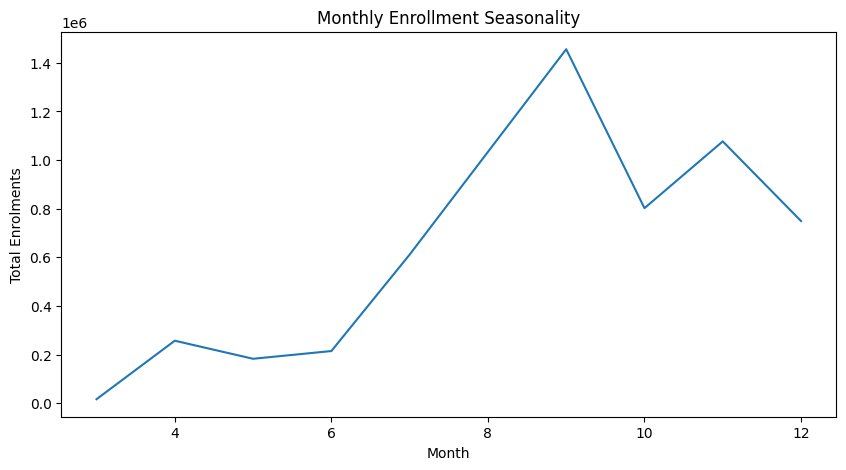

In [26]:
# Cell 4-1: Monthly enrollment pattern (seasonality)

monthly_core = (
    core_enrol_df
    .groupby("month", as_index=False)["total_enrolments"]
    .sum()
)

plt.figure()
plt.plot(monthly_core["month"], monthly_core["total_enrolments"])
plt.title("Monthly Enrollment Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Enrolments")
plt.show()


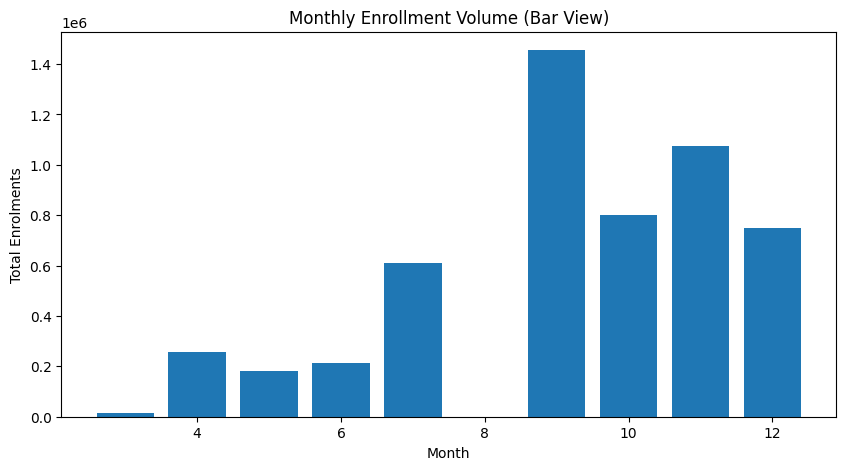

In [27]:
# Cell 4-2: Monthly enrollment seasonality (bar chart)

plt.figure()
plt.bar(
    monthly_core["month"],
    monthly_core["total_enrolments"]
)
plt.title("Monthly Enrollment Volume (Bar View)")
plt.xlabel("Month")
plt.ylabel("Total Enrolments")
plt.show()


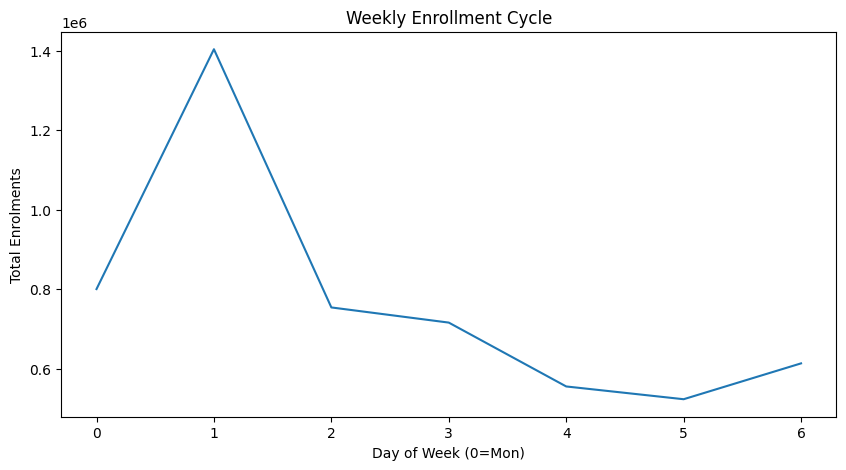

In [28]:
# Cell 4-3: Weekly cycle analysis (day-of-week behavior)

weekday_core = (
    core_enrol_df
    .groupby("day_of_week", as_index=False)["total_enrolments"]
    .sum()
)

plt.figure()
plt.plot(
    weekday_core["day_of_week"],
    weekday_core["total_enrolments"]
)
plt.title("Weekly Enrollment Cycle")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Total Enrolments")
plt.show()


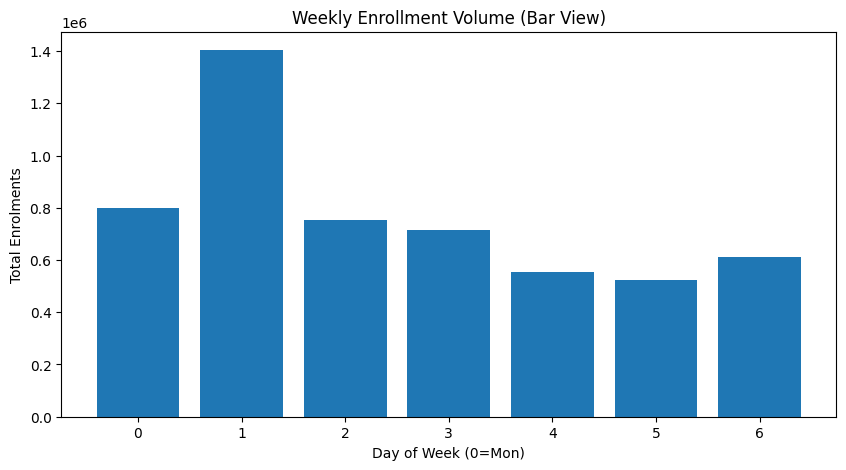

In [29]:
# Cell 4-4: Weekly cycle (bar chart)

plt.figure()
plt.bar(
    weekday_core["day_of_week"],
    weekday_core["total_enrolments"]
)
plt.title("Weekly Enrollment Volume (Bar View)")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Total Enrolments")
plt.show()


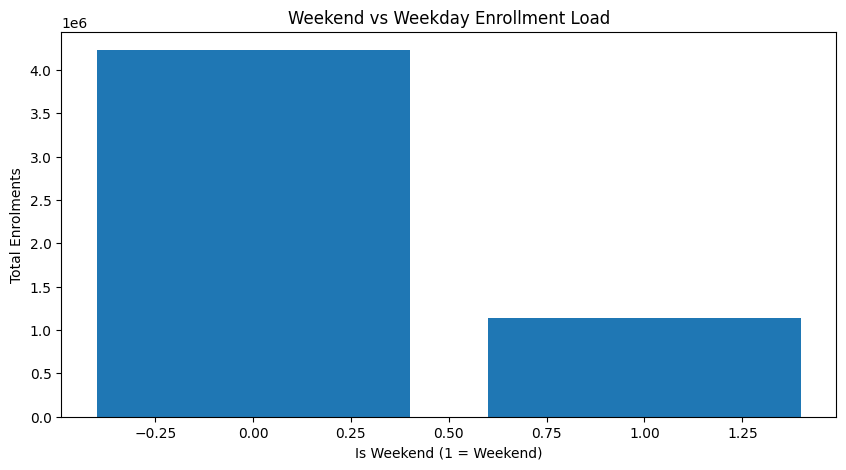

In [30]:
# Cell 4-5: Weekend vs weekday enrollment load

weekend_core = (
    core_enrol_df
    .groupby("is_weekend", as_index=False)["total_enrolments"]
    .sum()
)

plt.figure()
plt.bar(
    weekend_core["is_weekend"],
    weekend_core["total_enrolments"]
)
plt.title("Weekend vs Weekday Enrollment Load")
plt.xlabel("Is Weekend (1 = Weekend)")
plt.ylabel("Total Enrolments")
plt.show()


In [31]:
# Cell 4-6: Weekend dependency ratio (system reliance on weekends)

weekend_ratio = (
    weekend_core.loc[weekend_core["is_weekend"] == 1, "total_enrolments"].values[0] /
    weekend_core["total_enrolments"].sum()
)

weekend_ratio


np.float64(0.21180402023814648)

In [32]:
# Cell 4-7: Region-level weekend dependency (state behavior)

state_weekend = (
    core_enrol_df
    .groupby(["state_clean", "is_weekend"], as_index=False)["total_enrolments"]
    .sum()
)

state_weekend_pivot = (
    state_weekend
    .pivot(index="state_clean", columns="is_weekend", values="total_enrolments")
    .fillna(0)
)

state_weekend_pivot["weekend_dependency"] = (
    state_weekend_pivot.get(1, 0) /
    state_weekend_pivot.sum(axis=1)
)

state_weekend_pivot.sort_values("weekend_dependency", ascending=False).head(10)


is_weekend,0,1,weekend_dependency
state_clean,,,
The Dadra And Nagar Haveli And Daman And Diu,467.0,249.0,0.347765
Haryana,70929.0,27323.0,0.278091
Himachal Pradesh,12817.0,4669.0,0.267014
Jharkhand,115696.0,41843.0,0.265604
Jammu and Kashmir,36227.0,12869.0,0.262119
Ladakh,462.0,155.0,0.251216
Bihar,459911.0,149674.0,0.245534
Manipur,10223.0,3233.0,0.240265
Delhi,72457.0,22072.0,0.233494


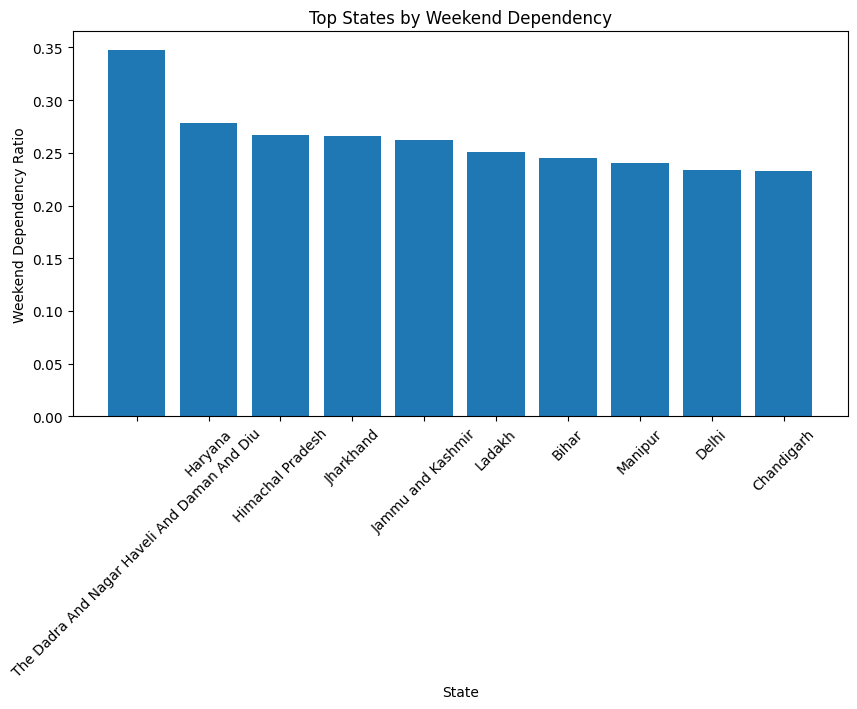

In [33]:
# Cell 4-8: Visualize high weekend-dependent states

top_weekend_states = (
    state_weekend_pivot
    .sort_values("weekend_dependency", ascending=False)
    .head(10)
)

plt.figure()
plt.bar(
    top_weekend_states.index,
    top_weekend_states["weekend_dependency"]
)
plt.title("Top States by Weekend Dependency")
plt.xlabel("State")
plt.ylabel("Weekend Dependency Ratio")
plt.xticks(rotation=45)
plt.show()


In [35]:
# Cell 5-1 (FIXED): State-level volume and volatility (behavioral)

# Daily enrollment per state
state_daily = (
    core_enrol_df
    .groupby(["state_clean", "date"], as_index=False)["total_enrolments"]
    .sum()
)

# State-level volume
state_volume = (
    state_daily
    .groupby("state_clean", as_index=False)["total_enrolments"]
    .sum()
    .rename(columns={"total_enrolments": "state_total_enrolments"})
)

# State-level volatility (std / mean across days)
state_volatility = (
    state_daily
    .groupby("state_clean")["total_enrolments"]
    .agg(["mean", "std"])
    .reset_index()
)

state_volatility["state_volatility_index"] = (
    state_volatility["std"] / state_volatility["mean"]
)

# Merge behavior metrics
state_behavior = state_volume.merge(
    state_volatility[["state_clean", "state_volatility_index"]],
    on="state_clean",
    how="left"
)

state_behavior.head()


,state_clean,state_total_enrolments,state_volatility_index
0,Andaman and Nicobar Islands,511,0.706586
1,Andhra Pradesh,127686,0.623744
2,Arunachal Pradesh,4344,1.037744
3,Assam,230197,2.168881
4,Bihar,609585,1.284527


In [36]:
# Cell 5-2: Normalize state behavior metrics (comparability)

state_behavior["volume_norm"] = (
    (state_behavior["state_total_enrolments"] - state_behavior["state_total_enrolments"].mean()) /
    state_behavior["state_total_enrolments"].std()
)

state_behavior["volatility_norm"] = (
    (state_behavior["state_volatility_index"] - state_behavior["state_volatility_index"].mean()) /
    state_behavior["state_volatility_index"].std()
)

state_behavior[["state_clean", "volume_norm", "volatility_norm"]].head()


,state_clean,volume_norm,volatility_norm
0,Andaman and Nicobar Islands,-0.662401,-0.541623
1,Andhra Pradesh,-0.047938,-0.652691
2,Arunachal Pradesh,-0.643881,-0.097632
3,Assam,0.447358,1.418906
4,Bihar,2.280423,0.233235


In [38]:
# Cell 5-3: Behavioral typology segmentation (volume × volatility)

# Define thresholds using medians (robust to skew)
volume_thresh = state_behavior["state_total_enrolments"].median()
volatility_thresh = state_behavior["state_volatility_index"].median()

def classify_region(row):
    if row["state_total_enrolments"] >= volume_thresh and row["state_volatility_index"] < volatility_thresh:
        return "High Volume – Stable (Mature)"
    elif row["state_total_enrolments"] >= volume_thresh and row["state_volatility_index"] >= volatility_thresh:
        return "High Volume – Volatile (Strained)"
    elif row["state_total_enrolments"] < volume_thresh and row["state_volatility_index"] >= volatility_thresh:
        return "Low Volume – Volatile (Fragile)"
    else:
        return "Low Volume – Stable"

state_behavior["behavior_type"] = state_behavior.apply(classify_region, axis=1)

state_behavior["behavior_type"].value_counts()


behavior_type
High Volume – Volatile (Strained)    15
Low Volume – Stable                  14
High Volume – Stable (Mature)         5
Low Volume – Volatile (Fragile)       5
Name: count, dtype: int64

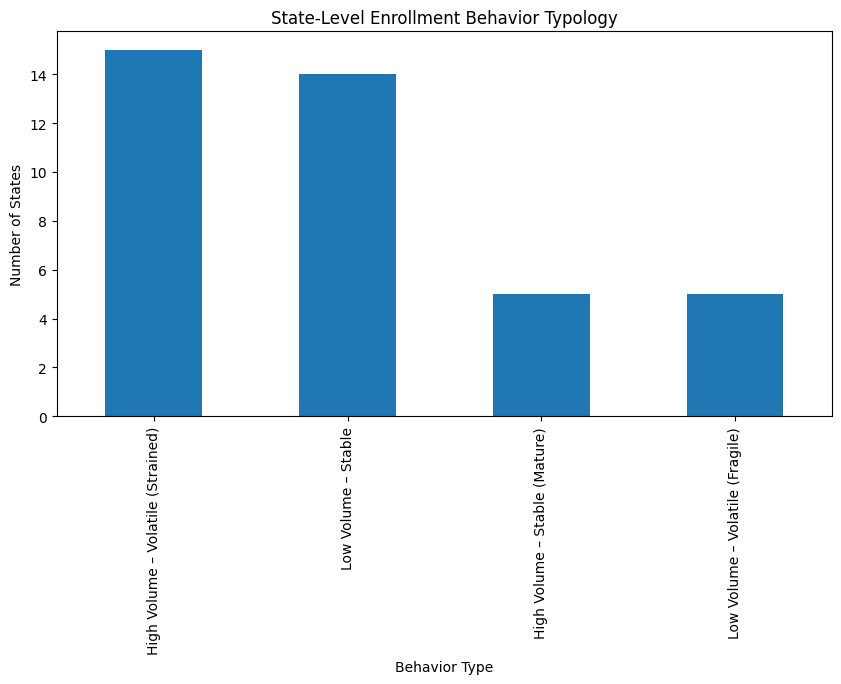

In [39]:
# Cell 5-4: Visualize regional behavior typology

behavior_counts = state_behavior["behavior_type"].value_counts()

plt.figure()
behavior_counts.plot(kind="bar")
plt.xlabel("Behavior Type")
plt.ylabel("Number of States")
plt.title("State-Level Enrollment Behavior Typology")
plt.show()


In [40]:
# Cell 5-5: Inspect representative states from each behavior type

state_behavior.sort_values(
    ["behavior_type", "state_total_enrolments"],
    ascending=[True, False]
).groupby("behavior_type").head(3)


,state_clean,state_total_enrolments,state_volatility_index,volume_norm,volatility_norm,volatility_segment,volume_segment,behavior_type
30,Tamil Nadu,220789,0.643440,0.401902,-0.626283,Medium Volatility,High Volume,High Volume – Stable (Mature)
31,Telangana,131574,0.785961,-0.029152,-0.435203,Medium Volatility,Medium Volume,High Volume – Stable (Mature)
1,Andhra Pradesh,127686,0.623744,-0.047938,-0.652691,Medium Volatility,Medium Volume,High Volume – Stable (Mature)
34,Uttar Pradesh,1018629,1.599631,4.256775,0.655701,High Volatility,High Volume,High Volume – Volatile (Strained)
4,Bihar,609585,1.284527,2.280423,0.233235,High Volatility,High Volume,High Volume – Volatile (Strained)
19,Madhya Pradesh,493970,1.309769,1.721813,0.267076,High Volatility,High Volume,High Volume – Volatile (Strained)
13,Jammu and Kashmir,49096,0.758322,-0.427656,-0.472259,Medium Volatility,Medium Volume,Low Volume – Stable
35,Uttarakhand,37698,0.799329,-0.482727,-0.417280,Medium Volatility,Medium Volume,Low Volume – Stable
12,Himachal Pradesh,17486,0.727254,-0.580384,-0.513912,Medium Volatility,Medium Volume,Low Volume – Stable
24,Nagaland,15587,3.137724,-0.589559,2.717852,High Volatility,Medium Volume,Low Volume – Volatile (Fragile)


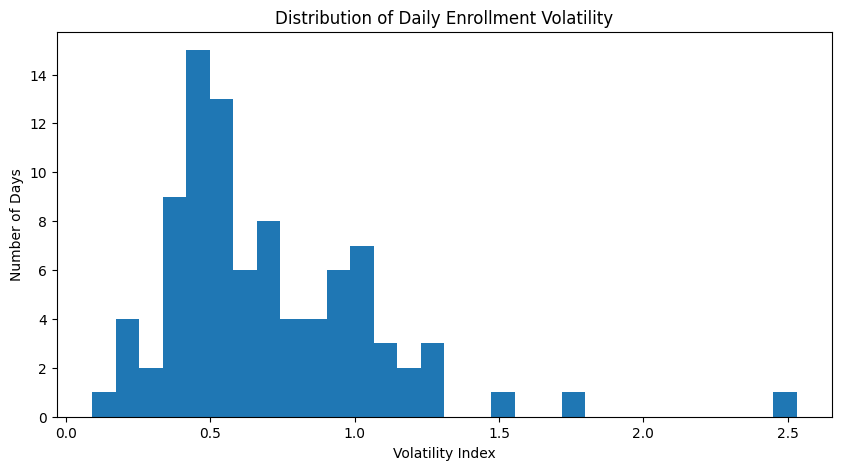

In [41]:
# Cell 6-1: Daily system stress profile (volatility distribution)

plt.figure()
daily_vol = daily_core["volatility_index"].dropna()
plt.hist(daily_vol, bins=30)
plt.xlabel("Volatility Index")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Enrollment Volatility")
plt.show()


In [42]:
# Cell 6-2: Identify high-stress days (top decile volatility)

stress_threshold = daily_core["volatility_index"].quantile(0.90)
high_stress_days = daily_core[
    daily_core["volatility_index"] >= stress_threshold
][["date", "total_enrolments", "volatility_index"]]

high_stress_days.head()


,date,total_enrolments,volatility_index
8,2025-03-29,67,1.229494
9,2025-04-01,257206,2.531275
10,2025-05-01,182890,1.721271
11,2025-06-01,214684,1.257759
12,2025-07-01,611281,1.211241


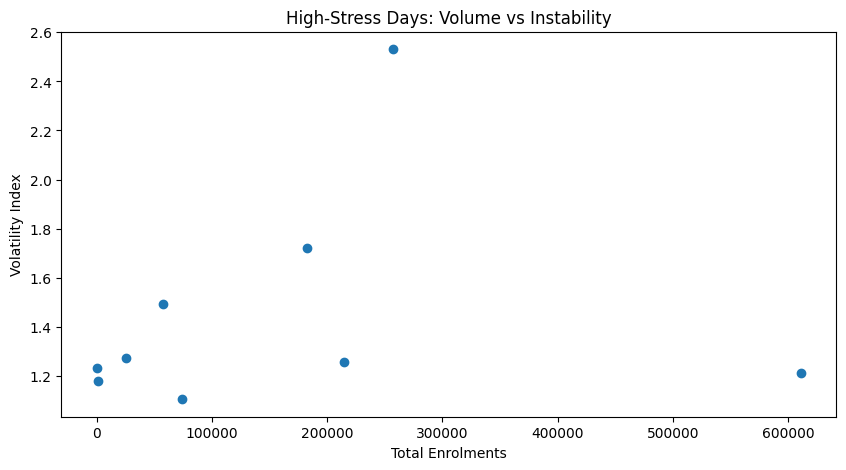

In [43]:
# Cell 6-3: Volume vs volatility on stress days

plt.figure()
plt.scatter(
    high_stress_days["total_enrolments"],
    high_stress_days["volatility_index"]
)
plt.xlabel("Total Enrolments")
plt.ylabel("Volatility Index")
plt.title("High-Stress Days: Volume vs Instability")
plt.show()


In [44]:
# Cell 7-1: Frequency of stress events per state

state_stress_days = (
    adv_enrol_df.merge(
        daily_core[["date", "volatility_index"]],
        on="date",
        how="left"
    )
    .query("volatility_index >= @stress_threshold")
    .groupby("state_clean")["date"]
    .nunique()
    .sort_values(ascending=False)
)

state_stress_days.head(10)


state_clean
Meghalaya        9
Bihar            8
Delhi            8
Haryana          8
Chhattisgarh     8
Assam            8
West Bengal      8
Uttar Pradesh    8
Uttarakhand      8
Rajasthan        8
Name: date, dtype: int64

In [45]:
# Cell 7-2: Chronically unstable states (persistent stress exposure)

chronically_unstable = state_stress_days[
    state_stress_days >= state_stress_days.quantile(0.75)
]

chronically_unstable


state_clean
Meghalaya         9
Bihar             8
Delhi             8
Haryana           8
Chhattisgarh      8
Assam             8
West Bengal       8
Uttar Pradesh     8
Uttarakhand       8
Rajasthan         8
Madhya Pradesh    8
Maharashtra       8
Manipur           8
Gujarat           8
Tamil Nadu        8
Telangana         8
Mizoram           8
Karnataka         8
Punjab            8
Nagaland          8
Name: date, dtype: int64

In [46]:
# Cell 8-1: Enrollment composition consistency (child share variability)

state_child_volatility = (
    core_enrol_df
    .groupby(["state_clean", "date"])["child_share"]
    .mean()
    .groupby("state_clean")
    .std()
    .sort_values(ascending=False)
)

state_child_volatility.head(10)


state_clean
Meghalaya           0.205262
Goa                 0.179909
Ladakh              0.149046
Nagaland            0.141533
Mizoram             0.127593
Assam               0.124106
Himachal Pradesh    0.116038
Manipur             0.113870
Sikkim              0.107285
Kerala              0.101832
Name: child_share, dtype: float64

In [47]:
# Cell 9-1: Decision-oriented summary table

decision_summary = state_behavior.merge(
    chronically_unstable.rename("stress_day_count"),
    on="state_clean",
    how="left"
).fillna({"stress_day_count": 0})

decision_summary.sort_values(
    ["behavior_type", "stress_day_count"],
    ascending=[True, False]
).head(10)


,state_clean,state_total_enrolments,state_volatility_index,volume_norm,volatility_norm,volatility_segment,volume_segment,behavior_type,stress_day_count
30,Tamil Nadu,220789,0.643440,0.401902,-0.626283,Medium Volatility,High Volume,High Volume – Stable (Mature),8.0
31,Telangana,131574,0.785961,-0.029152,-0.435203,Medium Volatility,Medium Volume,High Volume – Stable (Mature),8.0
1,Andhra Pradesh,127686,0.623744,-0.047938,-0.652691,Medium Volatility,Medium Volume,High Volume – Stable (Mature),0.0
16,Kerala,75002,0.781186,-0.302488,-0.441605,Medium Volatility,Medium Volume,High Volume – Stable (Mature),0.0
25,Odisha,122987,0.653466,-0.070641,-0.612842,Medium Volatility,Medium Volume,High Volume – Stable (Mature),0.0
22,Meghalaya,109771,3.752443,-0.134496,3.542019,High Volatility,Medium Volume,High Volume – Volatile (Strained),9.0
3,Assam,230197,2.168881,0.447358,1.418906,High Volatility,High Volume,High Volume – Volatile (Strained),8.0
4,Bihar,609585,1.284527,2.280423,0.233235,High Volatility,High Volume,High Volume – Volatile (Strained),8.0
6,Chhattisgarh,103219,0.862643,-0.166153,-0.332393,Medium Volatility,Medium Volume,High Volume – Volatile (Strained),8.0
8,Delhi,94529,2.046318,-0.208140,1.254583,High Volatility,Medium Volume,High Volume – Volatile (Strained),8.0


In [48]:
# Cell 10-1: Regions to prioritize for anomaly modeling

priority_regions = decision_summary[
    (decision_summary["behavior_type"].isin([
        "High Volume – Volatile (Strained)",
        "Low Volume – Volatile (Fragile)"
    ])) &
    (decision_summary["stress_day_count"] > 0)
]

priority_regions[["state_clean", "behavior_type", "stress_day_count"]]


,state_clean,behavior_type,stress_day_count
3,Assam,High Volume – Volatile (Strained),8.0
4,Bihar,High Volume – Volatile (Strained),8.0
6,Chhattisgarh,High Volume – Volatile (Strained),8.0
8,Delhi,High Volume – Volatile (Strained),8.0
10,Gujarat,High Volume – Volatile (Strained),8.0
11,Haryana,High Volume – Volatile (Strained),8.0
15,Karnataka,High Volume – Volatile (Strained),8.0
19,Madhya Pradesh,High Volume – Volatile (Strained),8.0
20,Maharashtra,High Volume – Volatile (Strained),8.0
21,Manipur,Low Volume – Volatile (Fragile),8.0
